# Sabriya Sowers' Notebook
# P2: Text Preprocessing

REQ: Open notebooks with a standard header including a good title, your company/name/alias, a link to the repo, purpose, and date.

- Author: [Sabriya Sowers](https://github.com/ssowers2)
- Repository: [nlp-02-text-preprocessing](https://github.com/ssowers2/nlp-02-text-preprocessing)
- Purpose: Demonstrate text pre-processing
- Date: 2026-03

This is a Markdown cell.

## Section 1. Setup and Imports

Imports and configuration appear once, at the top.

WHY:
- Keeps notebooks readable and reproducible
- Mirrors professional scripts
- Makes requirements clear

This is a Markdown cell.

In [16]:
# Section 1 Python cell.

# Imports at the top of the file
# REQ: External packages must be defined in pyproject.toml
# REQ: External packages must be installed in the environment using `uv sync` command
# REQ: External packages used in this notebook must be imported here

from pathlib import Path
import re

import matplotlib.pyplot as plt
import polars as pl

print("Imports complete.")

Imports complete.


## Section 2. Read the Text Data

This is a Markdown cell.

In [17]:
# Section 2 Python cell

# In notebooks, start with the current working directory
# where the notebook is located.
NOTEBOOKS_PATH: Path = Path.cwd()
ROOT_PATH: Path = NOTEBOOKS_PATH.parent

DATA_PATH: Path = ROOT_PATH / "data"
NOTEBOOKS_PATH: Path = ROOT_PATH / "notebooks"
SCRIPTS_PATH: Path = ROOT_PATH / "scripts"

# Choose a text file to analyze.
# Each line is treated as one text record.
input_path: Path = DATA_PATH / "text_data_sowers.txt"

# Read all lines from the file.
text_list: list[str] = input_path.read_text(encoding="utf-8").splitlines()

# Remove blank lines.
text_list = [line.strip() for line in text_list if line.strip()]

print("Data loaded successfully.")
print(f"Loaded {len(text_list):,} text records.")

# Combine all text rows into one large string for simple preprocessing.
raw_text: str = " ".join(text_list)

print(f"Raw text length: {len(raw_text):,} characters")
print("First 550 characters of raw text:")
print(raw_text[:550])

Data loaded successfully.
Loaded 5 text records.
Raw text length: 504 characters
First 550 characters of raw text:
Yorkshire Terriers, often called Yorkies, are small dogs known for their energetic personalities and long silky coats. Originally bred in England, Yorkies were used to catch rats in textile mills. Today they are popular companion animals and are known for being loyal and affectionate with their owners. Yorkies require regular grooming to maintain their coats and benefit from daily exercise and mental stimulation. Despite their small size, Yorkies are confident and often behave like much larger dogs.


## Section 3. Inspect the Raw Text

This is a Markdown cell.

In [18]:
# Section 3 Python cell
# Review the text records before preprocessing.
# This helps confirm the data loaded correctly and gives a sense of the structure of the text.

print("First 3 text records:")
for line in text_list[:3]:
    print("-", line)

print(f"\nLoaded {len(text_list):,} text records.")
print(f"Raw text length: {len(raw_text):,} characters")

print("\nFirst 550 characters of combined text:")
print(raw_text[:550])

First 3 text records:
- Yorkshire Terriers, often called Yorkies, are small dogs known for their energetic personalities and long silky coats.
- Originally bred in England, Yorkies were used to catch rats in textile mills.
- Today they are popular companion animals and are known for being loyal and affectionate with their owners.

Loaded 5 text records.
Raw text length: 504 characters

First 550 characters of combined text:
Yorkshire Terriers, often called Yorkies, are small dogs known for their energetic personalities and long silky coats. Originally bred in England, Yorkies were used to catch rats in textile mills. Today they are popular companion animals and are known for being loyal and affectionate with their owners. Yorkies require regular grooming to maintain their coats and benefit from daily exercise and mental stimulation. Despite their small size, Yorkies are confident and often behave like much larger dogs.


## Section 4. Tokenize the Raw Text

This is a Markdown cell.

In [19]:
# Section 4 Python cell

# Split the raw text into rough word-like pieces using whitespace.
raw_tokens: list[str] = raw_text.split()
count_of_raw_tokens: int = len(raw_tokens)

print("First 20 raw tokens:")
print(raw_tokens[:20])
print(f"Total raw tokens: {count_of_raw_tokens:,}")

First 20 raw tokens:
['Yorkshire', 'Terriers,', 'often', 'called', 'Yorkies,', 'are', 'small', 'dogs', 'known', 'for', 'their', 'energetic', 'personalities', 'and', 'long', 'silky', 'coats.', 'Originally', 'bred', 'in']
Total raw tokens: 77


## Section 5. Normalize the Text

This is a Markdown cell.

In [20]:
# Section 5 Python cell

# Convert all text to lowercase so words like "Data" and "data"
# are treated as the same token.
lower_text: str = raw_text.lower()

print("First 550 characters of lowercase text:")
print(lower_text[:550])

First 550 characters of lowercase text:
yorkshire terriers, often called yorkies, are small dogs known for their energetic personalities and long silky coats. originally bred in england, yorkies were used to catch rats in textile mills. today they are popular companion animals and are known for being loyal and affectionate with their owners. yorkies require regular grooming to maintain their coats and benefit from daily exercise and mental stimulation. despite their small size, yorkies are confident and often behave like much larger dogs.


## Section 6. Remove Punctuation and Tokenize Again


This is a Markdown cell.

In [21]:
# Section 6 Python cell

# Replace any character that is not a letter, number, or whitespace
# with a space. This removes punctuation and many special characters.
no_punct_text: str = re.sub(r"[^a-z0-9\s]", " ", lower_text)

# Tokenize again after punctuation removal.
tokens_no_punct: list[str] = no_punct_text.split()
count_of_tokens_no_punct: int = len(tokens_no_punct)

print("First 20 tokens after lowercasing and punctuation removal:")
print(tokens_no_punct[:20])
print(f"Total tokens after punctuation removal: {count_of_tokens_no_punct:,}")

First 20 tokens after lowercasing and punctuation removal:
['yorkshire', 'terriers', 'often', 'called', 'yorkies', 'are', 'small', 'dogs', 'known', 'for', 'their', 'energetic', 'personalities', 'and', 'long', 'silky', 'coats', 'originally', 'bred', 'in']
Total tokens after punctuation removal: 77


## Section 7. Remove Stop Words


This is a Markdown cell.

In [22]:
# Section 7 Python cell

# Stop words are very common words that often add little meaning
# for simple frequency analysis.
STOP_WORDS: set[str] = {
    "a",
    "an",
    "and",
    "are",
    "as",
    "at",
    "be",
    "but",
    "by",
    "for",
    "from",
    "has",
    "have",
    "in",
    "is",
    "it",
    "its",
    "of",
    "on",
    "or",
    "that",
    "the",
    "to",
    "was",
    "were",
    "will",
    "with",
}

# Keep only tokens that:
# - are longer than 2 characters
# - are not in the stop word list
clean_tokens: list[str] = [
    token for token in tokens_no_punct if len(token) > 2 and token not in STOP_WORDS
]

count_of_clean_tokens: int = len(clean_tokens)

print("First 20 cleaned tokens:")
print(clean_tokens[:20])
print(f"Total cleaned tokens: {count_of_clean_tokens:,}")

First 20 cleaned tokens:
['yorkshire', 'terriers', 'often', 'called', 'yorkies', 'small', 'dogs', 'known', 'their', 'energetic', 'personalities', 'long', 'silky', 'coats', 'originally', 'bred', 'england', 'yorkies', 'used', 'catch']
Total cleaned tokens: 58


## Section 8. Build a Before/After Summary Table


This is a Markdown cell.

In [23]:
# Section 8 Python cell

summary_df: pl.DataFrame = pl.DataFrame(
    {
        "stage": [
            "raw tokens",
            "after punctuation removal",
            "after stop word removal",
        ],
        "count": [
            count_of_raw_tokens,
            count_of_tokens_no_punct,
            count_of_clean_tokens,
        ],
    }
)

print("Preprocessing summary:")
print(summary_df)

Preprocessing summary:
shape: (3, 2)
┌───────────────────────────┬───────┐
│ stage                     ┆ count │
│ ---                       ┆ ---   │
│ str                       ┆ i64   │
╞═══════════════════════════╪═══════╡
│ raw tokens                ┆ 77    │
│ after punctuation removal ┆ 77    │
│ after stop word removal   ┆ 58    │
└───────────────────────────┴───────┘


### Insights

The dataset contains 77 tokens, which remains the same after punctuation removal. After removing stop words, the total decreases to 58 tokens. This shows that many common words are present in the text and that removing them helps reduce the dataset to more meaningful terms.

## Section 9. Build a Frequency Table with Polars

This is a Markdown cell.

In [24]:
# Section 9 Python cell

# Create a Polars DataFrame with one row per cleaned token.
token_df: pl.DataFrame = pl.DataFrame({"token": clean_tokens})

# Group by token, count occurrences, and sort from most common to least common.
freq_df: pl.DataFrame = token_df.group_by("token").len().sort("len", descending=True)

print("Top 5 most frequent cleaned tokens:")
print(freq_df.head(5))

Top 5 most frequent cleaned tokens:
shape: (5, 2)
┌─────────┬─────┐
│ token   ┆ len │
│ ---     ┆ --- │
│ str     ┆ u64 │
╞═════════╪═════╡
│ yorkies ┆ 4   │
│ their   ┆ 4   │
│ coats   ┆ 2   │
│ dogs    ┆ 2   │
│ small   ┆ 2   │
└─────────┴─────┘


### Insights

The most frequent tokens are "their", "yorkies", "often", "known," and "coats." These words clearly relate to the topic of Yorkshire Terriers, showing that the text focuses on characteristics and descriptions of the dogs.

## Section 10. Build a "Most Frequent Cleaned Tokens" Bar Chart


This is a Markdown cell.

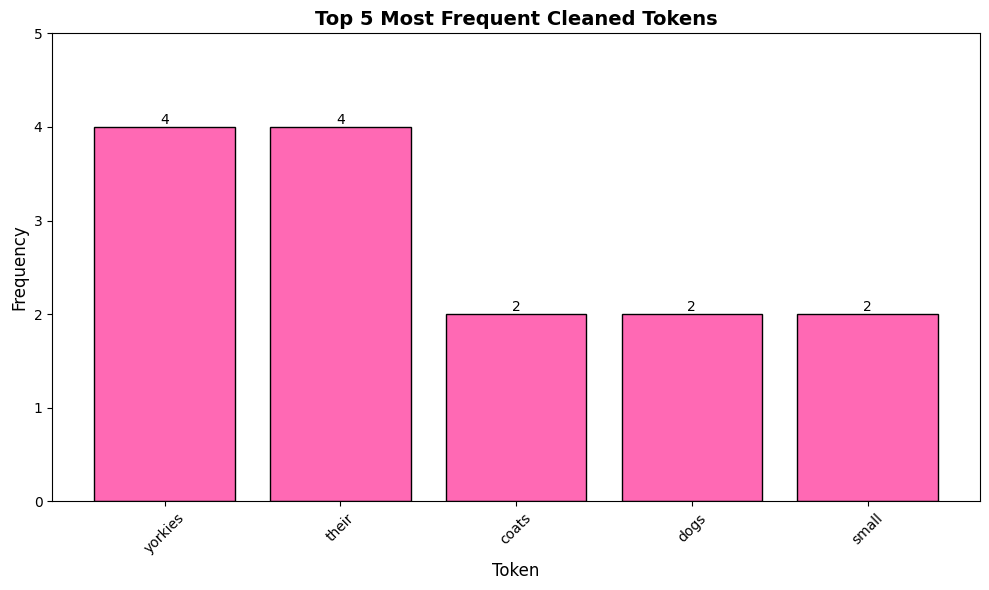

In [25]:
# Section 10 Python cell

top_df: pl.DataFrame = freq_df.head(5)

plt.figure(figsize=(10, 6))

# Added color and edge styling
bars = plt.bar(top_df["token"], top_df["len"], color="#FF69B4", edgecolor="black")

ax = plt.gca()
ax.tick_params(axis="x", labelrotation=45)

# Improved titles and labels
plt.title("Top 5 Most Frequent Cleaned Tokens", fontsize=14, fontweight="bold")
plt.xlabel("Token", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

# Add data labels above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2, height, int(height), ha='center', va='bottom'
    )

plt.ylim(0, 5)

plt.tight_layout()
plt.show()

### Insights

The bar chart highlights that "yorkies" and "their" are the most frequent tokens, followed by "often," "known," and "coats." The visualization makes it easy to see which terms appear most often and emphasizes the main themes in the dataset.

## Section 11. Compare Raw vs Clean Token Counts


This is a Markdown cell.

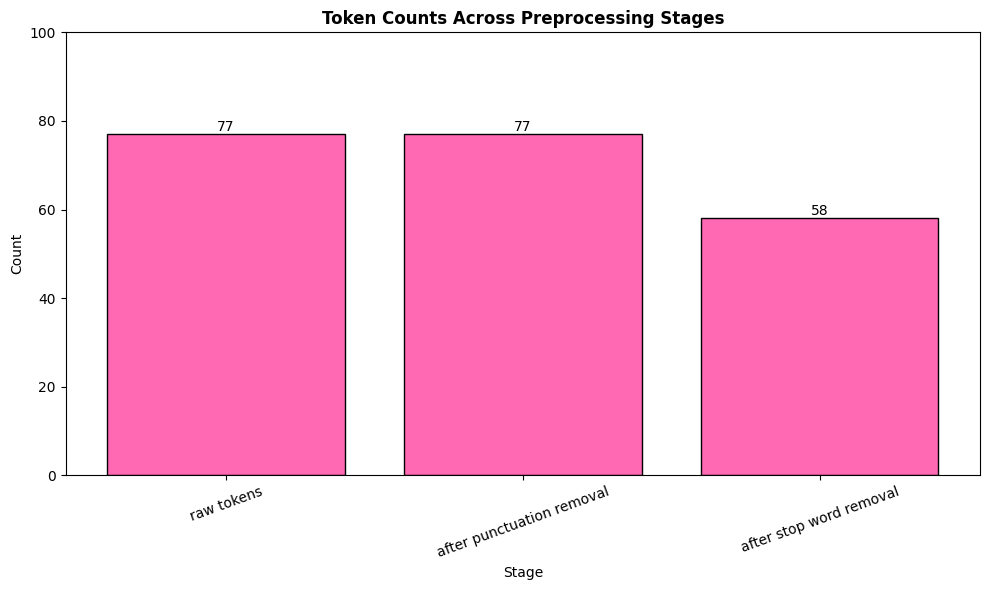

In [26]:
# Section 11 Python cell

plt.figure(figsize=(10, 6))

# Added color and edge styling
bars = plt.bar(
    summary_df["stage"], summary_df["count"], color="#FF69B4", edgecolor="black"
)

ax = plt.gca()
ax.tick_params(axis="x", labelrotation=20)

plt.title("Token Counts Across Preprocessing Stages", fontweight="bold")
plt.xlabel("Stage")
plt.ylabel("Count")

# Add data labels above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        str(int(height)),
        ha="center",
        va="bottom",
    )

plt.ylim(0, 100)

plt.tight_layout()
plt.show()

### Insights

The chart shows that the number of tokens remains at 77 after punctuation removal and decreases to 58 after stop word removal. This indicates that stop word removal plays a key role in reducing the dataset and focusing on more meaningful words.

## Reminder: "Run All" before sending to GitHub

Before saving a notebook (and running git add-commit-push),
**click 'Run All'** to generate all outputs and display them in the notebook. 

After git add-commit-push, **verify your notebook appears** in your GitHub repo. 

This is a Markdown cell.
